In [3]:
import pandas as pd
import numpy as np

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [4]:
df = pd.read_csv("../../data/raw/delays/flights_sample_3m.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [5]:
print("Dataset Shape:", df.shape)

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Dataset Shape: (3000000, 32)

Number of Rows: 3000000
Number of Columns: 32


In [6]:
df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",1155,1151.0,-4.0,19.0,1210.0,1443.0,4.0,1501,1447.0,-14.0,0.0,NaN,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",2120,2114.0,-6.0,9.0,2123.0,2232.0,38.0,2315,2310.0,-5.0,0.0,NaN,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",954,1000.0,6.0,20.0,1020.0,1247.0,5.0,1252,1252.0,0.0,0.0,NaN,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",1609,1608.0,-1.0,27.0,1635.0,1844.0,9.0,1829,1853.0,24.0,0.0,NaN,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",1840,1838.0,-2.0,15.0,1853.0,2026.0,14.0,2041,2040.0,-1.0,0.0,NaN,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  object 
 1   AIRLINE                  object 
 2   AIRLINE_DOT              object 
 3   AIRLINE_CODE             object 
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   object 
 7   ORIGIN_CITY              object 
 8   DEST                     object 
 9   DEST_CITY                object 
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED                float64
 21  CANCELLA

In [8]:
# Missing values
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage
})

missing_df

,Missing Values,Percentage (%)
CANCELLATION_CODE,2920860,97.362000
DELAY_DUE_LATE_AIRCRAFT,2466137,82.204567
DELAY_DUE_CARRIER,2466137,82.204567
DELAY_DUE_SECURITY,2466137,82.204567
DELAY_DUE_NAS,2466137,82.204567
DELAY_DUE_WEATHER,2466137,82.204567
ARR_DELAY,86198,2.873267
ELAPSED_TIME,86198,2.873267
AIR_TIME,86198,2.873267
WHEELS_ON,79944,2.664800


In [9]:
# Missing value summary
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage
})

missing_df = missing_df[missing_df["Missing Values"] > 0]
missing_df = missing_df.sort_values(by="Percentage (%)", ascending=False)

missing_df

,Missing Values,Percentage (%)
CANCELLATION_CODE,2920860,97.362000
DELAY_DUE_WEATHER,2466137,82.204567
DELAY_DUE_NAS,2466137,82.204567
DELAY_DUE_SECURITY,2466137,82.204567
DELAY_DUE_LATE_AIRCRAFT,2466137,82.204567
DELAY_DUE_CARRIER,2466137,82.204567
AIR_TIME,86198,2.873267
ELAPSED_TIME,86198,2.873267
ARR_DELAY,86198,2.873267
TAXI_IN,79944,2.664800


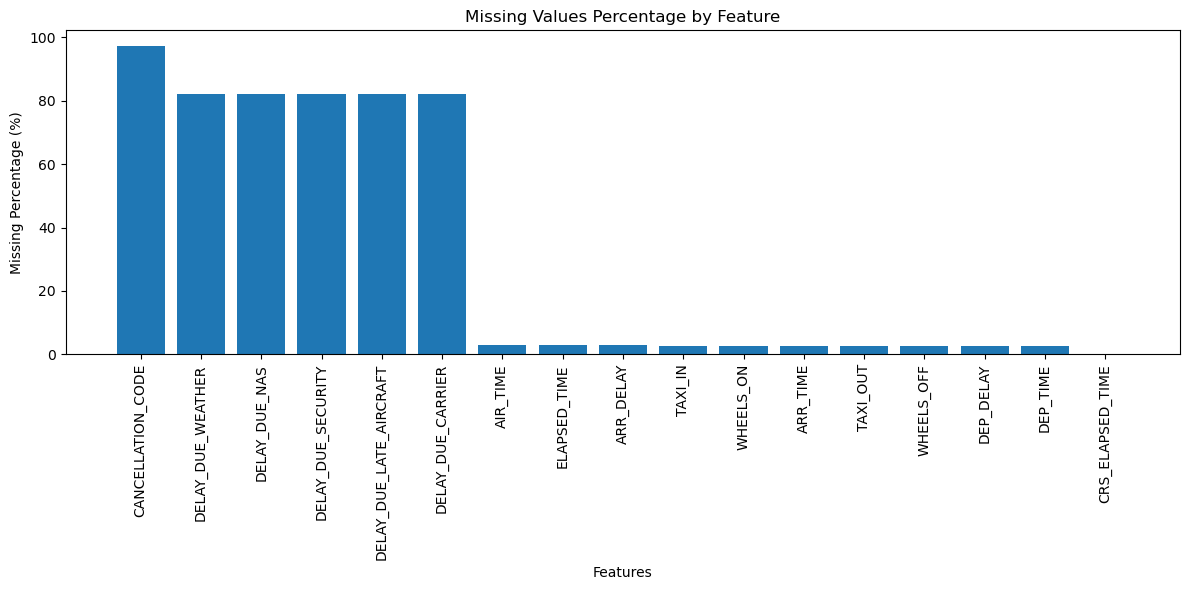

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(missing_df.index, missing_df["Percentage (%)"])

plt.xticks(rotation=90)
plt.ylabel("Missing Percentage (%)")
plt.xlabel("Features")
plt.title("Missing Values Percentage by Feature")

plt.tight_layout()
plt.show()

In [11]:
duplicate_count = df.duplicated().sum()

print("Duplicate Records:", duplicate_count)

Duplicate Records: 0


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
DOT_CODE,3000000.0,19976.294095,377.284619,19393.0,19790.0,19930.0,20368.0,20452.0
FL_NUMBER,3000000.0,2511.535519,1747.258040,1.0,1051.0,2152.0,3797.0,9562.0
CRS_DEP_TIME,3000000.0,1327.061984,485.878854,1.0,915.0,1320.0,1730.0,2359.0
DEP_TIME,2922385.0,1329.775913,499.310052,1.0,916.0,1323.0,1739.0,2400.0
DEP_DELAY,2922356.0,10.123326,49.251835,-90.0,-6.0,-2.0,6.0,2966.0
TAXI_OUT,2921194.0,16.643046,9.192901,1.0,11.0,14.0,19.0,184.0
WHEELS_OFF,2921194.0,1352.360989,500.872687,1.0,931.0,1336.0,1752.0,2400.0
WHEELS_ON,2920056.0,1462.499569,527.236818,1.0,1049.0,1501.0,1908.0,2400.0
TAXI_IN,2920056.0,7.678982,6.269639,1.0,4.0,6.0,9.0,249.0
CRS_ARR_TIME,3000000.0,1490.560665,511.547566,1.0,1107.0,1516.0,1919.0,2400.0


In [13]:
df.nunique().sort_values(ascending=False)

FL_NUMBER                  7111
DISTANCE                   1727
FL_DATE                    1704
ARR_DELAY                  1527
DEP_DELAY                  1513
WHEELS_OFF                 1440
WHEELS_ON                  1440
DEP_TIME                   1440
ARR_TIME                   1440
CRS_ARR_TIME               1435
CRS_DEP_TIME               1384
DELAY_DUE_CARRIER          1291
DELAY_DUE_LATE_AIRCRAFT     958
DELAY_DUE_WEATHER           812
ELAPSED_TIME                696
DELAY_DUE_NAS               671
AIR_TIME                    666
CRS_ELAPSED_TIME            640
ORIGIN                      380
DEST                        380
ORIGIN_CITY                 373
DEST_CITY                   373
TAXI_IN                     202
TAXI_OUT                    179
DELAY_DUE_SECURITY          172
AIRLINE_DOT                  18
AIRLINE                      18
DOT_CODE                     18
AIRLINE_CODE                 18
CANCELLATION_CODE             4
DIVERTED                      2
CANCELLE

In [14]:
print("=" * 50)
print("Flight Delay Dataset Overview")
print("=" * 50)

print(f"Number of Records : {df.shape[0]:,}")
print(f"Number of Features: {df.shape[1]}")

Flight Delay Dataset Overview
Number of Records : 3,000,000
Number of Features: 32


In [15]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

print("Categorical Features:", len(categorical_cols))
print(categorical_cols)

print("\nNumerical Features:", len(numerical_cols))
print(numerical_cols)

Categorical Features: 9
['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY', 'CANCELLATION_CODE']

Numerical Features: 23
['DOT_CODE', 'FL_NUMBER', 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'CANCELLED', 'DIVERTED', 'CRS_ELAPSED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT']
